In [1]:


%%capture
# capture는 주렁주렁 출력 보여주지 않게끔
# 그래프에서 한글이 깨지지 않게 폰트 설치..
# *맨처음에 셀 한 번 실행하고 세션 다시 시작하고 또 실행해야 반영됨!!
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [2]:
%%capture
!pip install gdown
!pip install transformers
!pip install sentencepiece # MarianTokenizer 불러올 때 필요
!pip install sacremoses # MarianMTModel 에서 불러올 때 warning 뜨는 것 방지
!pip install einops # Einstein operations => rearrange 함수를 위해

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from transformers import MarianMTModel, MarianTokenizer # MT: Machine Translation
import pandas as pd
from tqdm import tqdm
import math, random
from einops import rearrange

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Mounted at /content/drive
cuda


In [4]:
# for random seed
random_seed = 0
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed) # if use multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
random.seed(random_seed)

In [5]:
# Load the tokenizer & model
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-ko-en')
model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-ko-en') # MT: Machine Translation
# input_embedding = model.get_input_embeddings() # 일부 사이즈 큰 놈들은 데려와서 나머지만 학습시키려는 시도
# input_embedding.weight.requires_grad = False # freeze
# fc_out = model.get_output_embeddings()
# fc_out.weight.requires_grad = False

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [6]:
eos_idx = tokenizer.eos_token_id
pad_idx = tokenizer.pad_token_id
print("eos_idx = ", eos_idx)
print("pad_idx = ", pad_idx)

eos_idx =  0
pad_idx =  65000


## 하이퍼파라미터 조정

In [7]:
BATCH_SIZE = 64 # 논문에선 2.5만 token이 한 batch에 담기게 했다고 함.
LAMBDA = 0 # l2-Regularization를 위한 hyperparam. # 저장된 모델
EPOCH = 15 # 저장된 모델
# max_len = 512 # model.model.encoder.embed_positions 를 보면 512로 했음을 알 수 있다.
max_len = 100 # 너무 긴거 같아서 자름 (GPU 부담도 많이 덜어짐)
criterion = nn.CrossEntropyLoss(ignore_index = pad_idx) # pad token 이 출력 나와야하는 시점의 loss는 무시 (즉, label이 <pad> 일 때는 무시) # 저장된 모델
# criterion = nn.CrossEntropyLoss(ignore_index = pad_idx, label_smoothing = 0.1) # 막상 해보니 성능 안나옴 <- 데이터가 많아야 할 듯

scheduler_name = 'Noam'
# scheduler_name = 'Cos'
#### Noam ####
# warmup_steps = 4000 # 이건 논문에서 제시한 값 (총 10만 step의 4%)
warmup_steps = 1000 # 데이터 수 * EPOCH / BS = 총 step 수 인것 고려 # 저장된 모델
LR_scale = 0.5 # Noam scheduler에 peak LR 값 조절을 위해 곱해질 녀석 # 저장된 모델
#### Cos ####
LR_init = 5e-4
T0 = 1500 # 첫 주기
T_mult = 2 # 배 만큼 주기가 길어짐 (1보다 큰 정수여야 함)
#############

new_model_train = False
hyuk_model_use = True # 여러분만의 모델 만들어서 사용하고 싶다면 False로

if hyuk_model_use:
    !gdown https://drive.google.com/uc?id=1bjbeWgqlVKJ9gzDcL1hfD9cIItQy9_N2 -O Transformer_small.pt
    !gdown https://drive.google.com/uc?id=1M0yYP2umxlwaAbk_iq5G_Z5y3qLu9Wet -O Transformer_small_history.pt

    save_model_path = 'Transformer_small.pt'
    save_history_path = 'Transformer_small_history.pt'
else:
    save_model_path = '/content/drive/MyDrive/Colab Notebooks/results/Transformer_small2.pt'
    save_history_path = '/content/drive/MyDrive/Colab Notebooks/results/Transformer_small2_history.pt'

Downloading...
From (original): https://drive.google.com/uc?id=1bjbeWgqlVKJ9gzDcL1hfD9cIItQy9_N2
From (redirected): https://drive.google.com/uc?id=1bjbeWgqlVKJ9gzDcL1hfD9cIItQy9_N2&confirm=t&uuid=3914a7bf-cb06-412a-9c25-402f91a8e99a
To: /content/Transformer_small.pt
100% 448M/448M [00:02<00:00, 199MB/s]
Downloading...
From: https://drive.google.com/uc?id=1M0yYP2umxlwaAbk_iq5G_Z5y3qLu9Wet
To: /content/Transformer_small_history.pt
100% 1.39k/1.39k [00:00<00:00, 6.24MB/s]


In [8]:
# 논문에 나오는 base 모델 (train loss를 많이 줄이려면 많은 Epoch이 요구됨, 또, test 성능도 좋으려면 더 많은 데이터 요구)
# n_layers = 6
# d_model = 512
# d_ff = 2048
# n_heads = 8
# drop_p = 0.1

# 좀 사이즈 줄인 모델 (훈련된 input_embedding, fc_out 사용하면 사용 불가)
n_layers = 3
d_model = 256
d_ff = 512
n_heads = 8
drop_p = 0.1
print("n_layers = ", n_layers)
print("d_model = ", d_model)
print("d_ff = ", d_ff)
print("n_heads = ", n_heads)
print("drop_p = ",drop_p )

n_layers =  3
d_model =  256
d_ff =  512
n_heads =  8
drop_p =  0.1


## 토크나이저 & 학습된 모델 써보기

In [9]:
# tokenizer 써보기 (_로 띄어쓰기를 나타낸다! 즉, _가 없으면 이어진 한 단어임을 나타냄 subword tokenizing)
# 토크나이저에 대해 참고 자료: https://ratsgo.github.io/nlpbook/docs/preprocess/bpe/
print(tokenizer.tokenize("Hi, I'm Hyuk. ...        a   a?"))
print(tokenizer.tokenize("a/b 1+2+3 2:1 a>b"))
print(tokenizer.tokenize("pretrained restart"))
print(tokenizer.tokenize("chatGPT"))
print(tokenizer.tokenize("The example is very good in our lecture")) # 띄어쓰기도 tokenize 할 때가 있다.
print(tokenizer.tokenize("한글은 어떻게 할까?"))
print(tokenizer.tokenize("확실히 띄어쓰기 기준으로 토크나이징을 하는 것 같진 않다."))
print(tokenizer.tokenize("여러분들 차례!"))

['▁H', 'i', ',', '▁I', "'", 'm', '▁H', 'y', 'u', 'k', '.', '▁', '...', '▁a', '▁a', '?']
['▁a', '/', 'b', '▁1', '+2', '+3', '▁2:', '1', '▁a', '>', 'b']
['▁p', 're', 'tra', 'in', 'ed', '▁re', 'st', 'art']
['▁ch', 'at', 'G', 'P', 'T']
['▁The', '▁', 'ex', 'am', 'ple', '▁is', '▁', 'very', '▁good', '▁in', '▁', 'our', '▁', 'le', 'c', 'ture']
['▁한', '글', '은', '▁어떻게', '▁할까', '?']
['▁확실히', '▁띄', '어', '쓰기', '▁기준으로', '▁토', '크', '나이', '징', '을', '▁하는', '▁것', '▁같', '진', '▁않다', '.']
['▁여러분들', '▁차례', '!']


In [10]:
print(tokenizer.get_vocab())
vocab_size = tokenizer.vocab_size
print(vocab_size)

print(tokenizer.encode('지능', add_special_tokens=False)) # string to index
print(tokenizer.encode('<pad>', add_special_tokens=False)) # <pad>는 65000
print(tokenizer.encode('</s>', add_special_tokens=False)) # <sos> or <eos>는 0
print(tokenizer.encode('He', add_special_tokens=False)) # add_special_tokens=False 는 <eos> 자동 붙여주는 것을 방지
print(tokenizer.encode('he', add_special_tokens=False)) # 대소문자 다른 단어로 인식
print(tokenizer.tokenize('문장을 넣으면 토크나이즈해서 숫자로 바꾼다'))
print(tokenizer.encode('문장을 넣으면 토크나이즈해서 숫자로 바꾼다', add_special_tokens=False))
print(tokenizer.decode([204]))
print(tokenizer.decode([206]))
print(tokenizer.decode([210]))
print(tokenizer.decode(list(range(15)) + [65000,65001,65002,65003]))

{'</s>': 0, '<unk>': 1, '.': 2, ',': 3, '▁the': 4, '▁to': 5, '▁of': 6, '?': 7, '▁and': 8, '▁': 9, 's': 10, '▁a': 11, "'": 12, '▁in': 13, '▁들': 14, '▁that': 15, '▁I': 16, '▁”': 17, '▁you': 18, '▁“': 19, '▁is': 20, '▁이': 21, '▁-': 22, '▁을': 23, '▁it': 24, '▁의': 25, '▁for': 26, '▁은': 27, '!': 28, '▁에': 29, '▁’': 30, '▁be': 31, '▁‘': 32, '▁with': 33, '▁not': 34, '▁was': 35, '▁have': 36, '▁we': 37, '▁are': 38, '▁on': 39, '▁가': 40, '▁는': 41, '▁this': 42, '▁를': 43, '▁그': 44, '▁—': 45, ':': 46, '’': 47, '이': 48, 't': 49, '▁as': 50, '을': 51, ')': 52, '의': 53, '▁한': 54, '는': 55, '▁they': 56, '▁The': 57, '▁(': 58, '▁he': 59, '▁his': 60, '▁will': 61, '가': 62, '▁God': 63, '에': 64, '▁from': 65, '...': 66, '▁can': 67, '▁by': 68, '▁your': 69, '▁And': 70, '▁what': 71, '▁do': 72, '▁all': 73, '▁에서': 74, '▁me': 75, '▁으로': 76, '▁their': 77, '▁or': 78, '를': 79, '▁one': 80, '▁who': 81, '▁them': 82, '▁at': 83, '▁my': 84, '고': 85, '▁[': 86, '▁You': 87, '▁과': 88, '▁로': 89, '▁Jehovah': 90, '▁It': 91, '은': 92, '▁

In [11]:
# 사전 학습된 모델로 번역해보기 (생각보다 성능 좋네)
input_text = "헐! 대박 쩐다!"

input_tokens = tokenizer.encode(input_text, return_tensors="pt")
translated_tokens = model.generate(input_tokens, max_new_tokens=max_len)
translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

print("입력:", input_text)
print("AI의 번역:", translated_text)

입력: 헐! 대박 쩐다!
AI의 번역: Oh, my God! That's awesome!


## DS, DL 생성 & 테스트

In [12]:
# data 다운
# %%capture
# https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=126 에서 받을 수 있어요
!gdown https://drive.google.com/uc?id=1r4ZnFJOStyBlNRx7snBQ-Iq2GNyJKL6t -O '대화체.xlsx'
data = pd.read_excel('대화체.xlsx')

Downloading...
From: https://drive.google.com/uc?id=1r4ZnFJOStyBlNRx7snBQ-Iq2GNyJKL6t
To: /content/대화체.xlsx
100% 9.57M/9.57M [00:00<00:00, 24.5MB/s]


In [13]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data.loc[idx, '원문'], self.data.loc[idx, '번역문']

custom_DS = CustomDataset(data)

train_DS, val_DS, test_DS = torch.utils.data.random_split(custom_DS, [97000, 2000, 1000])
# 논문에서는 450만개 영,독 문장 pair 사용

train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_DS))
print(len(val_DS))
print(len(test_DS))

97000
2000
1000


In [14]:
# test_DS 확인
i = 5
src_text, trg_text = test_DS[i]

print(f"인덱스: {test_DS.indices[i]}")  # 엑셀 파일에서 idx+2번째 문장에 들어있음을 확인할 수 있다 (엑셀은 1번째 시작하고 1열엔 "원문", "번역문" 이런 열 정보가 써있음)
print(f"원문: {src_text}")
print(f"번역문: {trg_text}")

인덱스: 19993
원문: 나도 그랬으면 좋겠지만 겨울까지 휴가 못 가.
번역문: I wish I could, but I can't go on vacation until winter.


In [15]:
# train_DL 테스트
for src_texts, trg_texts in train_DL:

    print(src_texts)
    print(trg_texts)
    print(len(src_texts))
    print(len(trg_texts))

    # 여러 문장에 대해서는 tokenizer.encode() 가 아닌 그냥 tokenizer()
    src = tokenizer(src_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt', add_special_tokens = False).input_ids # pt: pytorch tensor로 변환
    # add_special_tokens = True (default)면 마지막에 <eos> 를 붙임
    # truncation = True: max_len 보다 길면 끊고 <eos> 집어넣어버림
    trg_texts = ['</s> ' + s for s in trg_texts]
    # <sos>가 토크나이저에 따로 없길래 </s> 를 <sos> 로도 사용
    trg = tokenizer(trg_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt').input_ids

    print(src[:2])
    print(trg[:2])
    print(src.shape)
    print(trg.shape)
    print(trg[:,-1]) # 가장 마지막 단어를 보니 어떤 문장은 <eos> 로 끝이 났고 나머지는 <pad> 로 끝이 났다는 걸 볼 수 있음
    print(tokenizer.decode(trg[trg[:,-1]==eos_idx,:][0])) # 가장 긴 문장 중 첫 번째 문장 관찰
    print(trg[5,:-1]) # 디코더 입력
    print(trg[5,1:]) # 디코더 출력
    # 그런데 [:,:-1] 로 주면 패딩된 문장은 eos도 넣는 셈 아닌가? 맞다! 하지만 괜찮다. 어차피 출력으로 pad token이 기다리고 있으니.. (loss에서 ignore됨)

    break

('아메리카노 1잔과 샌드위치 1개를 내일 아침 제 방으로 가져다주세요.', '아닙니다, 바로 다음에 나올 음식을 손님께 드리도록 할게요.', '2인분 추가 주문하면 음식이 나오는 데 얼마나 걸릴까요?', '일러스트 프로그램은 추가로 설치를 하셔야 하는데, 30분 정도 시간이 걸릴 것입니다.', '여기 이 부분이요, 아까 설명해주신 거랑 좀 다른 것 같은데요?', '그 제품은 품절되어 현재 남은 물량이 없습니다.', '새 상품과 기존에 받으셨던 상품의 맞교환으로 진행해드리겠습니다.', '그러게, 심지어 더치페이를 얼마를 해야 하는지 계산도 해줘.', '판매하는 핸드폰 케이스 종류를 늘려야 할인지도 모르겠어요.', '응, 식구들도 일찍 집에서 나가서 나를 깨워줄 사람이 없었어.', '하지만 꼭 인기 있는 주인공만 출연하는 것 같아.', '혹시 기내에서 카드 결제도 가능한가요?', '이 수박은 먹을 수도 없으니 환불 부탁드립니다.', '생각보다 음료가 너무 써서 그런데 시럽을 좀 추가할 수 있을까요?', '새로 계약하기로 했던 거 어떻게 되어가고 있어요?', '신경이 많이 쓰여서 웃을 때도 크게 안 웃거든요.', '마음에 드셨다니 다행이네요, 20분 정도 걸리는데 괜찮으세요?', '지금 퇴근하는 시간이라 차가 많이 막히지 않을까?', '그러면 저희 방으로 치킨을 시켜주실 수 있나요?', '한 팩에 물티슈가 100매 정도 들어 있습니다.', '체크인 시간은 11시까지인데, 혹시 언제 오세요?', '11일은 저희 쪽에서 힘들 것 같으니, 12일로 할 수 있을까요?', '장대리, 이번 우수실적 명단에 포함된 것 축하해.', '이 절에 가려면 버스를 타고 한 시간을 가야 해.', '다른 지점보다 훨씬 저렴하네요. 오늘 아무 때나 방문해도 될까요?', '몇 년간 꾸준히 SNS 활동을 했으며 이전에 상품 리뷰를 작성한 경험이 있는 사람들을 우선순위로 뽑았습니다.', '그러게, 아까 길 물어봤을 때 거기서 5분만 걸어가면 보인다고 했는데 말이지.', '요즘은 로봇 청소기보다 

In [16]:
# 내가 쓸 train data 에 대해서 MarianMTmodel이 잘 번역하는지 확인
src_text, trg_tex = test_DS[5]
print(f"입력: {src_text}")
print(f"정답: {trg_text}")

src = tokenizer.encode(src_text, return_tensors='pt', add_special_tokens = True)
# add_special_tokens = False 해보면 뭔가 이상하게 번역함 (학습 때 source에도 <eos>를 넣었단 증거?)
translated_tokens = model.generate(src, max_new_tokens=max_len)
translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=False)

print(f"AI의 번역: {translated_text}") # 디코더 첫 입력으로 <pad> 토큰을 넣었음. (<pad>를 <sos>로 사용)

입력: 나도 그랬으면 좋겠지만 겨울까지 휴가 못 가.
정답: I wish I could, but I can't go on vacation until winter.
AI의 번역: <pad> I wish I could, but I can't go on vacation until winter.</s>


## 모델 구현

### Multi-Head Attention

In [17]:
class MHA(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.fc_q = nn.Linear(d_model, d_model) # 차 or 개x차 or 개x개x차 로 입력해줘야
        self.fc_k = nn.Linear(d_model, d_model)
        self.fc_v = nn.Linear(d_model, d_model)
        self.fc_o = nn.Linear(d_model, d_model)
        self.scale = torch.sqrt(torch.tensor(d_model / n_heads))
    def forward(self, Q, K, V, mask = None):

        Q = self.fc_q(Q) # 개단차
        K = self.fc_k(K)
        V = self.fc_v(V)

        Q = rearrange(Q, '개 단 (헤 차) -> 개 헤 단 차', 헤 = self.n_heads) # 개단차 -> 개헤단차
        K = rearrange(K, '개 단 (헤 차) -> 개 헤 단 차', 헤 = self.n_heads)
        V = rearrange(V, '개 단 (헤 차) -> 개 헤 단 차', 헤 = self.n_heads)

        attention_score = Q @ K.transpose(-2,-1)/self.scale # 개헤단단

        if mask is not None:
            attention_score[mask] = -1e10

        attention_weights = torch.softmax(attention_score, dim=-1) # 개헤단단

        attention = attention_weights @ V # 개헤단차

        x = rearrange(attention, '개 헤 단 차 -> 개 단 (헤 차)') # 개헤단차 -> 개단차
        x = self.fc_o(x) # 개단차

        return x, attention_weights

        # einops를 알기전
        # batch_size = Q.shape[0]

        # Q = self.fc_q(Q) # 개단차
        # K = self.fc_k(K)
        # V = self.fc_v(V)

        # Q = Q.reshape(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3) # 개헤단차를 만들어줘야 한다 (QK^TV 연산을 위해)
        # K = K.reshape(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3) # 이 때, 개단차 -> 개단헤차 -> 개헤단차
        # V = V.reshape(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3) # 이 순서로 해야 reshape할 때 512를 8개로 쪼갬!!!

        # attention_score = Q@K.permute(0,1,3,2)/self.scale # 개헤단단

        # if mask is not None:
        #     attention_score[mask] = -1e10 # mask.shape = 개헤단단
        # attention_weights = torch.softmax(attention_score, dim=-1) # 개헤단단

        # attention = attention_weights @ V # 개헤단차

        # x = attention.permute(0,2,1,3) # 개단헤차
        # x = x.reshape(batch_size, -1, self.d_model) # 개단차

        # x = self.fc_o(x) # 개단차

        # return x, attention_weights

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, drop_p):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(d_model, d_ff),
                                    nn.ReLU(),
                                    nn.Dropout(drop_p), # 논문에는 명시되어 있지 않지만.. overfitting 취약한 부분이라
                                    nn.Linear(d_ff, d_model))

    def forward(self, x):
        x = self.linear(x)
        return x

#### rearrange, scaling 실험

In [18]:
Q = torch.randn(1, 4, 6) # 개단차
print(Q)

Q = rearrange(Q, '개 단 (헤 차) -> 개 헤 단 차', 헤 = 3) # 개단차 -> 개헤단차
# 주의! (차 헤) 로 해보면 또 다름. 차원의 수 6을 헤드의 수 3으로 쪼개는 것이므로 (헤 차) 가 맞다
print(Q)
print(Q.shape)

x = rearrange(Q, '개 헤 단 차 -> 개 단 (헤 차)') # 개헤단차 -> 개단차,
print(x)
print(x.shape)

tensor([[[ 0.2595, -0.4927, -0.4737, -0.2074, -1.9427, -1.7322],
         [-0.5939, -1.1785, -0.7656, -1.9260, -0.8876, -0.6519],
         [ 0.1413, -1.7858,  0.2259, -0.0683, -0.4737, -1.9399],
         [-1.4287, -0.6150,  0.4548,  0.8434,  1.2168, -0.7239]]])
tensor([[[[ 0.2595, -0.4927],
          [-0.5939, -1.1785],
          [ 0.1413, -1.7858],
          [-1.4287, -0.6150]],

         [[-0.4737, -0.2074],
          [-0.7656, -1.9260],
          [ 0.2259, -0.0683],
          [ 0.4548,  0.8434]],

         [[-1.9427, -1.7322],
          [-0.8876, -0.6519],
          [-0.4737, -1.9399],
          [ 1.2168, -0.7239]]]])
torch.Size([1, 3, 4, 2])
tensor([[[ 0.2595, -0.4927, -0.4737, -0.2074, -1.9427, -1.7322],
         [-0.5939, -1.1785, -0.7656, -1.9260, -0.8876, -0.6519],
         [ 0.1413, -1.7858,  0.2259, -0.0683, -0.4737, -1.9399],
         [-1.4287, -0.6150,  0.4548,  0.8434,  1.2168, -0.7239]]])
torch.Size([1, 4, 6])


In [19]:
# Q = torch.randn(1, 4, 6) # 개단차
# print(Q)

# Q = Q.reshape(1, -1, 3, 2).permute(0,2,1,3) # 개헤단차를 만들어줘야 한다 (QK^TV 연산을 위해)
# 이 때, 개단차 -> 개단헤차 -> 개헤단차
# 이 순서로 해야 reshape할 때 512를 8개로 쪼갬!!!
# print(Q)

# x = Q.permute(0,2,1,3) # 개단헤차
# x = x.reshape(1, -1, 6) # 개단차
# print(x)

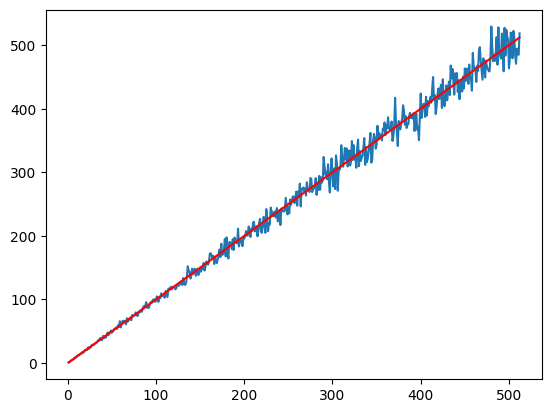

In [20]:
# 왜 scaling을 sqrt(dk) 로? <- 일단 나누는 이유: 안나누면 softmax로 들어갈때 분산이 크면 grad가 작아짐
n=torch.arange(1,513)
N=1000
result=[]
for ni in n:
    inner_prod = torch.zeros(N)
    for i in range(N):
        inner_prod[i] = torch.randn(ni,1).T@torch.randn(ni,1) # 내적값을 N번 구해서 var 구해보자
    result += [torch.var(inner_prod)]

plt.plot(n,result)
plt.plot(n,n,'r') # variance 가 점점커지니까 std로 나눠서 unit variance로 만들자는 것!

### Encoder

In [21]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, d_ff, n_heads, drop_p):
        super().__init__()

        self.self_atten = MHA(d_model, n_heads)
        self.self_atten_LN = nn.LayerNorm(d_model)

        self.FF = FeedForward(d_model, d_ff, drop_p)
        self.FF_LN = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(drop_p)

    def forward(self, x, enc_mask):

        residual, atten_enc = self.self_atten(x, x, x, enc_mask) # 인코더에도 마스크가?!
        residual = self.dropout(residual)
        x = self.self_atten_LN(x + residual)

        residual = self.FF(x)
        residual = self.dropout(residual)
        x = self.FF_LN(x + residual)

        return x, atten_enc

class Encoder(nn.Module):
    def __init__(self, input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p):
        super().__init__()

        self.scale = torch.sqrt(torch.tensor(d_model))
        self.input_embedding = input_embedding
        self.pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(drop_p)

        self.layers = nn.ModuleList([EncoderLayer(d_model, d_ff, n_heads, drop_p) for _ in range(n_layers)])

    def forward(self, src, mask, atten_map_save = False): # src.shape = 개단, mask.shape = 개헤단단

        pos = torch.arange(src.shape[1]).expand_as(src).to(DEVICE) # 개단

        x = self.scale*self.input_embedding(src) + self.pos_embedding(pos) # 개단차
        # self.scale 을 곱해주면 position 보다 token 정보를 더 보게 된다 (gradient에 self.scale 만큼이 더 곱해짐)
        x = self.dropout(x)

        atten_encs = torch.tensor([]).to(DEVICE)
        for layer in self.layers:
            x, atten_enc = layer(x, mask)
            if atten_map_save is True:
                atten_encs = torch.cat([atten_encs , atten_enc[0].unsqueeze(0)], dim=0) # 층헤단단 ㅋ

        return x, atten_encs

#### expand_as, nn.embedding 실험

In [22]:
src = torch.randint(0,65000,(3,5)) # 개단
pos = torch.arange(5).expand_as(src).to(DEVICE)
print(src)
print(pos)

tensor([[17852, 30557, 14802,   783,  2753],
        [13780,  2814, 59476, 54905, 10648],
        [21454, 17110, 22480,  4393, 46681]])
tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]], device='cuda:0')


In [23]:
# nn.Embedding 실험
emb=nn.Embedding(10,5) # one-hot encoding 된 벡터가 통과된다는 것이 약속된 상태의 FC layer 인 것
print(emb.weight.shape) # weight 개수는 nn.Linear(10,5) 과 동일! 동작 방식이 다른 것
print(emb(torch.tensor(2)))

print(emb(torch.tensor([[6,1,2],[2,1,7]]))) # 2 개 문장, 3개 단어
print(emb(torch.tensor([[6,1,2],[2,1,7]])).shape)

torch.Size([10, 5])
tensor([-1.6781, -0.4184,  0.3999,  1.5914,  0.1325],
       grad_fn=<EmbeddingBackward0>)
tensor([[[-0.2685, -0.1505, -0.4780,  1.2038,  3.6673],
         [-0.5822, -0.3072, -0.9433, -2.7531, -0.0236],
         [-1.6781, -0.4184,  0.3999,  1.5914,  0.1325]],

        [[-1.6781, -0.4184,  0.3999,  1.5914,  0.1325],
         [-0.5822, -0.3072, -0.9433, -2.7531, -0.0236],
         [-0.0108,  0.2441,  2.3384, -0.9031, -0.9961]]],
       grad_fn=<EmbeddingBackward0>)
torch.Size([2, 3, 5])


### Decoder, 모델 전체

In [24]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, d_ff, n_heads, drop_p):
        super().__init__()

        self.self_atten = MHA(d_model, n_heads)
        self.self_atten_LN = nn.LayerNorm(d_model)

        self.enc_dec_atten = MHA(d_model, n_heads)
        self.enc_dec_atten_LN = nn.LayerNorm(d_model)

        self.FF = FeedForward(d_model, d_ff, drop_p)
        self.FF_LN = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(drop_p)

    def forward(self, x, enc_out, dec_mask, enc_dec_mask):

        residual, atten_dec = self.self_atten(x, x, x, dec_mask)
        residual = self.dropout(residual)
        x = self.self_atten_LN(x + residual)

        residual, atten_enc_dec = self.enc_dec_atten(x, enc_out, enc_out, enc_dec_mask) # Q는 디코더로부터 K,V는 인코더로부터!!
        residual = self.dropout(residual)
        x = self.enc_dec_atten_LN(x + residual)

        residual = self.FF(x)
        residual = self.dropout(residual)
        x = self.FF_LN(x + residual)

        return x, atten_dec, atten_enc_dec

class Decoder(nn.Module):
    def __init__(self, input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p):
        super().__init__()

        self.scale = torch.sqrt(torch.tensor(d_model))
        self.input_embedding = input_embedding
        self.pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(drop_p)

        self.layers = nn.ModuleList([DecoderLayer(d_model, d_ff, n_heads, drop_p) for _ in range(n_layers)])

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, trg, enc_out, dec_mask, enc_dec_mask, atten_map_save = False): # trg.shape = 개단, enc_out.shape = 개단차, dec_mask.shape = 개헤단단

        pos = torch.arange(trg.shape[1]).expand_as(trg).to(DEVICE) # 개단

        x = self.scale*self.input_embedding(trg) + self.pos_embedding(pos) # 개단차
        # self.scale 을 곱해주면 position 보다 token 정보를 더 보게 된다 (gradient에 self.scale 만큼이 더 곱해짐)
        x = self.dropout(x)

        atten_decs = torch.tensor([]).to(DEVICE)
        atten_enc_decs = torch.tensor([]).to(DEVICE)
        for layer in self.layers:
            x, atten_dec, atten_enc_dec = layer(x, enc_out, dec_mask, enc_dec_mask)
            if atten_map_save is True:
                atten_decs = torch.cat([atten_decs , atten_dec[0].unsqueeze(0)], dim=0) # 층헤단단 ㅋ
                atten_enc_decs = torch.cat([atten_enc_decs , atten_enc_dec[0].unsqueeze(0)], dim=0) # 층헤단단 ㅋ

        x = self.fc_out(x)

        return x, atten_decs, atten_enc_decs

In [25]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, max_len, n_layers, d_model, d_ff, n_heads, drop_p):
        super().__init__()

        self.input_embedding = nn.Embedding(vocab_size, d_model)
        self.encoder = Encoder(self.input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p)
        self.decoder = Decoder(self.input_embedding, max_len, n_layers, d_model, d_ff, n_heads, drop_p)

        self.n_heads = n_heads

        # for m in self.modules():
        #     if hasattr(m,'weight') and m.weight.dim() > 1: # layer norm에 대해선 initial 안하겠다는 뜻
        #         nn.init.kaiming_uniform_(m.weight) # Kaiming의 분산은 2/Nin

        for m in self.modules():
            if hasattr(m,'weight') and m.weight.dim() > 1:
                nn.init.xavier_uniform_(m.weight) # xavier의 분산은 2/(Nin+Nout) 즉, 분산이 더 작다. => 그래서 sigmoid/tanh에 적합한 것! (vanishing gradient 막기 위해)

    def make_enc_mask(self, src): # src.shape = 개단

        enc_mask = (src == pad_idx).unsqueeze(1).unsqueeze(2) # 개11단
        enc_mask = enc_mask.expand(src.shape[0], self.n_heads, src.shape[1], src.shape[1]) # 개헤단단
        """ src pad mask (문장 마다 다르게 생김. 이건 한 문장에 대한 pad 행렬)
        F F T T
        F F T T
        F F T T
        F F T T
        """
        return enc_mask

    def make_dec_mask(self, trg): # trg.shape = 개단

        trg_pad_mask = (trg == pad_idx).unsqueeze(1).unsqueeze(2) # 개11단
        trg_pad_mask = trg_pad_mask.expand(trg.shape[0], self.n_heads, trg.shape[1], trg.shape[1]) # 개헤단단
        """ trg pad mask
        F F F T T
        F F F T T
        F F F T T
        F F F T T
        F F F T T
        """
        trg_future_mask = torch.tril(torch.ones(trg.shape[0], self.n_heads, trg.shape[1], trg.shape[1]))==0 # 개헤단단
        trg_future_mask = trg_future_mask.to(DEVICE) # pad_mask | future_mask 할 때 같은 DEVICE 여야
        """ trg future mask
        F T T T T
        F F T T T
        F F F T T
        F F F F T
        F F F F F
        """
        dec_mask = trg_pad_mask | trg_future_mask # dec_mask.shape = 개헤단단
        """ decoder mask
        F T T T T
        F F T T T
        F F F T T
        F F F T T
        F F F T T
        """
        return dec_mask

    def make_enc_dec_mask(self, src, trg):

        enc_dec_mask = (src == pad_idx).unsqueeze(1).unsqueeze(2) # 개11단
        enc_dec_mask = enc_dec_mask.expand(trg.shape[0], self.n_heads, trg.shape[1], src.shape[1]) # 개헤단단
        """ src pad mask
        F F T T
        F F T T
        F F T T
        F F T T
        F F T T
        """
        return enc_dec_mask

    def forward(self, src, trg):

        enc_mask = self.make_enc_mask(src)
        dec_mask = self.make_dec_mask(trg)
        enc_dec_mask = self.make_enc_dec_mask(src, trg)

        enc_out, atten_encs = self.encoder(src, enc_mask)
        out, atten_decs, atten_enc_decs = self.decoder(trg, enc_out, dec_mask, enc_dec_mask)

        return out, atten_encs, atten_decs, atten_enc_decs

#### tril, initialization 실험

In [26]:
# 즉, Layer norm은 initialization에서 제외!
print(nn.LayerNorm(10).weight)
print(nn.LayerNorm(10).weight.dim())

Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True)
1


In [27]:
# Kaiming vs Xavier
layer = nn.Linear(2,10)
print(layer.weight)
nn.init.kaiming_uniform_(layer.weight)
print(layer.weight) # in 만 보니까 분산 크다
nn.init.xavier_uniform_(layer.weight)
print(layer.weight) # in out 둘다 보니까 분산 작다

Parameter containing:
tensor([[-0.3944,  0.6439],
        [ 0.5155, -0.2986],
        [ 0.3603, -0.1287],
        [ 0.1776,  0.1751],
        [-0.4228,  0.0257],
        [-0.3353, -0.6263],
        [-0.0948,  0.0423],
        [ 0.4657,  0.4260],
        [ 0.5745,  0.1126],
        [-0.4502, -0.3011]], requires_grad=True)
Parameter containing:
tensor([[ 1.3684, -0.6090],
        [-0.6438, -1.2935],
        [ 1.2556,  0.4329],
        [-1.4143, -1.3268],
        [ 0.8475, -0.7028],
        [ 0.3444, -0.5987],
        [-0.5752, -1.3120],
        [ 0.9593, -0.2170],
        [ 0.7855, -0.1299],
        [-0.5891,  0.4474]], requires_grad=True)
Parameter containing:
tensor([[ 0.2238, -0.6880],
        [-0.2719,  0.3142],
        [-0.3369, -0.6052],
        [ 0.0813,  0.5083],
        [ 0.2164,  0.2459],
        [ 0.6930, -0.2376],
        [ 0.6302, -0.2040],
        [ 0.5373,  0.4957],
        [-0.6869,  0.1311],
        [ 0.0326, -0.4407]], requires_grad=True)


In [28]:
x = torch.ones(2,3,5,5)
print(x)
x = torch.tril(x) # tril: lower triangular
print(x)

tensor([[[[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]]]])
tensor([[[[1., 0., 0., 0.

## 모델 생성

In [29]:
model = Transformer(vocab_size, max_len, n_layers, d_model, d_ff, n_heads, drop_p).to(DEVICE)

src = torch.tensor([[4,6,5,1,1,1],[7,7,1,1,1,1]]).to(DEVICE)
trg = torch.tensor([[2,5,4,4,3,1,1],[2,9,6,7,3,1,1]]).to(DEVICE)

model.eval()
with torch.no_grad():
    x = model(src, trg)[0]
print(trg.shape)
print(x.shape)

torch.Size([2, 7])
torch.Size([2, 7, 65001])


## Train, Test, loss_epoch 함수

In [30]:
def Train(model, train_DL, val_DL, criterion, optimizer, scheduler = None):
    loss_history = {"train": [], "val": []}
    best_loss = 9999
    for ep in range(EPOCH):
        model.train() # train mode로 전환
        train_loss = loss_epoch(model, train_DL, criterion, optimizer = optimizer, scheduler = scheduler)
        loss_history["train"] += [train_loss]

        model.eval() # test mode로 전환
        with torch.no_grad():
            val_loss = loss_epoch(model, val_DL, criterion)
            loss_history["val"] += [val_loss]
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save({"model": model,
                            "ep": ep,
                            "optimizer": optimizer,
                            "scheduler": scheduler,}, save_model_path)
        # print loss
        print(f"Epoch {ep+1}: train loss: {train_loss:.5f}   val loss: {val_loss:.5f}   current_LR: {optimizer.param_groups[0]['lr']:.8f}")
        print("-" * 20)

    torch.save({"loss_history": loss_history,
                "EPOCH": EPOCH,
                "BATCH_SIZE": BATCH_SIZE}, save_history_path)

def Test(model, test_DL, criterion):
    model.eval() # test mode로 전환
    with torch.no_grad():
        test_loss = loss_epoch(model, test_DL, criterion)
    print(f"Test loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):.3f}")

def loss_epoch(model, DL, criterion, optimizer = None, scheduler = None):
    N = len(DL.dataset) # the number of data

    rloss=0
    for src_texts, trg_texts in tqdm(DL, leave=False):
        src = tokenizer(src_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt', add_special_tokens = False).input_ids.to(DEVICE)
        trg_texts = ['</s> ' + s for s in trg_texts]
        trg = tokenizer(trg_texts, padding=True, truncation=True, max_length = max_len, return_tensors='pt').input_ids.to(DEVICE)
        # inference
        y_hat = model(src, trg[:,:-1])[0] # 모델 통과 시킬 땐 trg의 마지막 토큰은 제외!
        # y_hat.shape = 개단차 즉, 훈련 땐 문장이 한번에 튀어나옴
        # loss
        loss = criterion(y_hat.permute(0,2,1), trg[:,1:]) # loss 계산 시엔 <sos> 는 제외!
        """
        개단차 -> 개차단으로 바꿔줌 (1D segmentation으로 생각)
        개채행열(예측), 개행열(정답)으로 주거나 개채1열, 개1열로 주거나 개채열, 개열로 줘야하도록 함수를 만들어놔서
        우리 상황에서는 개차단, 개단 으로 줘야 한다.
        이렇게 함수를 만들어놔야 1D, 2D segmentation 등등으로 확장가능하기 때문
        다 필요없고, 그냥 y_hat=개차단, trg=개단으로 줘야만 계산 제대로 된다고 생각하시면 됩니다!
        """
        # update
        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        # loss accumulation
        loss_b = loss.item() * src.shape[0]
        rloss += loss_b
    loss_e = rloss/N
    return loss_e

def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps, LR_scale = 1):
        self.optimizer = optimizer
        self.current_step = 0
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.LR_scale = LR_scale

    def step(self):
        self.current_step += 1
        lrate = self.LR_scale * (self.d_model ** -0.5) * min(self.current_step ** -0.5, self.current_step * self.warmup_steps ** -1.5)
        self.optimizer.param_groups[0]['lr'] = lrate

def plot_scheduler(scheduler_name, optimizer, scheduler, total_steps): # LR curve 보기
    lr_history = []
    steps = range(1, total_steps)

    for _ in steps: # base model -> 10만 steps (12시간), big model -> 30만 steps (3.5일) 로 훈련했다고 함
        lr_history += [optimizer.param_groups[0]['lr']]
        scheduler.step()

    plt.figure()
    if scheduler_name == 'Noam':
        if total_steps == 100000:
            plt.plot(steps, (512 ** -0.5) * torch.tensor(steps) ** -0.5, 'g--', linewidth=1, label=r"$d_{\mathrm{model}}^{-0.5} \cdot \mathrm{step}^{-0.5}$")
            plt.plot(steps, (512 ** -0.5) * torch.tensor(steps) * 4000 ** -1.5, 'r--', linewidth=1, label=r"$d_{\mathrm{model}}^{-0.5} \cdot \mathrm{step} \cdot \mathrm{warmup\_steps}^{-1.5}$")
        plt.plot(steps, lr_history, 'b', linewidth=2, alpha=0.8, label="Learning Rate")
    elif scheduler_name == 'Cos':
        plt.plot(steps, lr_history, 'b', linewidth=2, alpha=0.8, label="Learning Rate")
    plt.ylim([-0.1*max(lr_history), 1.2*max(lr_history)])
    plt.xlabel('Step')
    plt.ylabel('Learning Rate')
    plt.grid()
    plt.legend()
    plt.show()

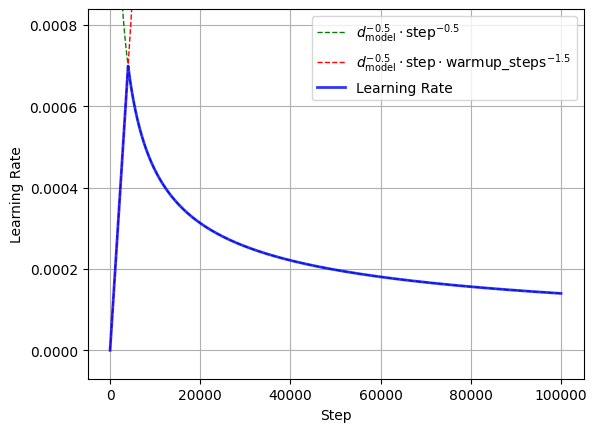

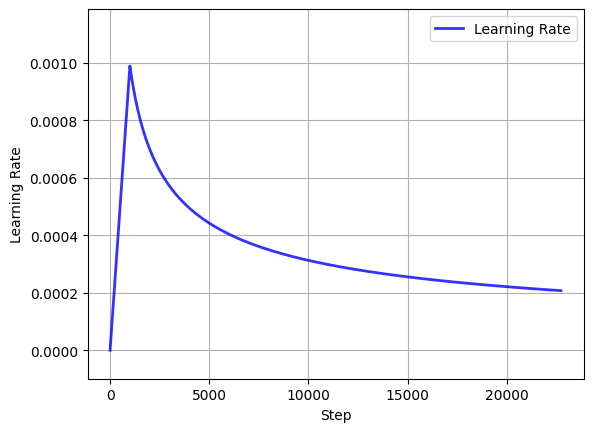

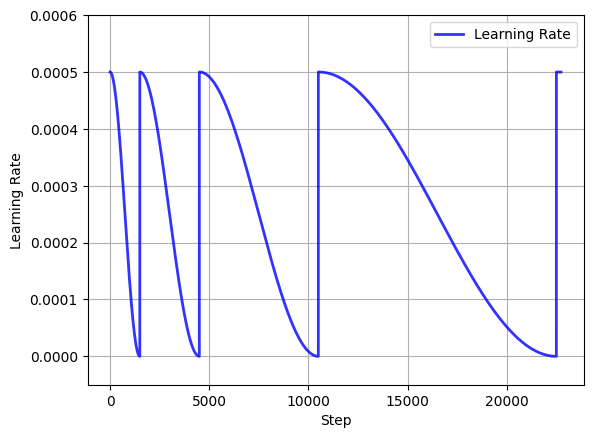

In [31]:
optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=0) # 테스트용 optimizer
scheduler = NoamScheduler(optimizer, d_model=512, warmup_steps=4000) # 논문 값
plot_scheduler(scheduler_name = 'Noam', optimizer = optimizer, scheduler = scheduler, total_steps = 100000)

optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=0)
scheduler = NoamScheduler(optimizer, d_model=d_model, warmup_steps=warmup_steps, LR_scale=LR_scale)
plot_scheduler(scheduler_name = 'Noam', optimizer = optimizer, scheduler = scheduler, total_steps = int(len(train_DS)*EPOCH/BATCH_SIZE)) # 내 상황

optimizer = optim.Adam(nn.Linear(1, 1).parameters(), lr=LR_init)
scheduler = CosineAnnealingWarmRestarts(optimizer, T0, T_mult)
plot_scheduler(scheduler_name = 'Cos', optimizer = optimizer, scheduler = scheduler, total_steps = int(len(train_DS)*EPOCH/BATCH_SIZE))

## 모델 학습

In [32]:
if new_model_train:
    params = [p for p in model.parameters() if p.requires_grad] # 사전 학습된 layer를 사용할 경우
    if scheduler_name == 'Noam':
        optimizer = optim.Adam(params, lr=0,
                               betas=(0.9, 0.98), eps=1e-9,
                               weight_decay=LAMBDA) # 논문에서 제시한 beta와 eps 사용, l2-Regularization은 한번 써봄 & 맨 처음 step 의 LR=0으로 출발 (warm-up)
        scheduler = NoamScheduler(optimizer, d_model=d_model, warmup_steps=warmup_steps, LR_scale=LR_scale)

    elif scheduler_name == 'Cos':
        optimizer = optim.Adam(params, lr=LR_init,  # cos restart sheduling
                               betas=(0.9, 0.98), eps=1e-9,
                               weight_decay=LAMBDA)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T0, T_mult)

    Train(model, train_DL, val_DL, criterion, optimizer, scheduler)

## 로드 모델

In [33]:
loaded = torch.load(save_model_path, map_location=DEVICE)
load_model = loaded["model"]
ep = loaded["ep"]
optimizer = loaded["optimizer"]

loaded = torch.load(save_history_path, map_location=DEVICE)
loss_history = loaded["loss_history"]

print(ep)
print(optimizer)

<ipython-input-33-c96f6b8a1623>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(save_model_path, map_location=DEVICE)


12
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.98)
    capturable: False
    differentiable: False
    eps: 1e-09
    foreach: None
    fused: None
    lr: 0.00022260183745731945
    maximize: False
    weight_decay: 0
)


<ipython-input-33-c96f6b8a1623>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(save_history_path, map_location=DEVICE)


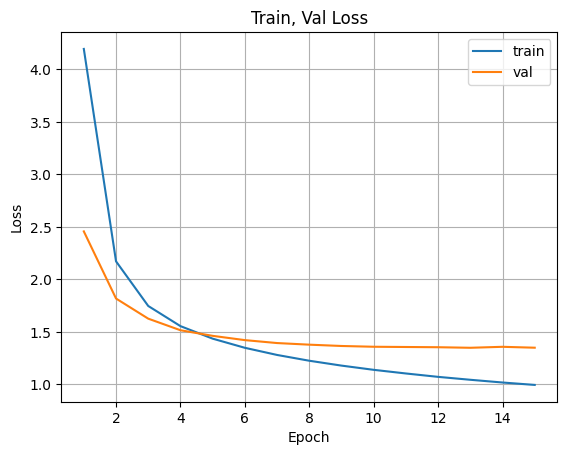

In [34]:
plt.figure()
plt.plot(range(1,EPOCH+1),loss_history["train"], label="train")
plt.plot(range(1,EPOCH+1),loss_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train, Val Loss")
plt.grid()
plt.legend()

In [35]:
Test(load_model, test_DL, criterion)
count_params(load_model)

Test loss: 1.325 | Test PPL: 3.761


37350377

In [36]:
# Perplxity 구하기
y_hat = torch.tensor([[[0.3659, 0.7025, 0.3104]], [[0.0097, 0.6577, 0.1947]],[[0.5659, 0.0025, 0.0104]], [[0.9097, 0.0577, 0.7947]]])
target = torch.tensor([[2],  [1], [2],  [1]])

soft = nn.Softmax(dim=-1)
y_hat_soft = soft(y_hat)
print(y_hat_soft.shape)
v=1
for i, val in enumerate(y_hat_soft):
    v*=val[0,target[i]]
print(v**(-1/target.shape[0]))
# 3.5257

criterion_test = nn.CrossEntropyLoss()
print(y_hat.permute(0,2,1).shape)
print(target.shape)
print(torch.exp(criterion_test(y_hat.permute(0,2,1), target))) # 결론: loss에 torch.exp 취하셈
# 3.5257

torch.Size([4, 1, 3])
tensor([3.5257])
torch.Size([4, 3, 1])
torch.Size([4, 1])
tensor(3.5257)


## 번역 함수, 어텐션 map 그리는 함수

In [37]:
def translation(model, src_text, atten_map_save = False):
    model.eval()
    with torch.no_grad():
        src = tokenizer.encode(src_text, return_tensors='pt', add_special_tokens=False).to(DEVICE) # 1x단
        enc_mask = model.make_enc_mask(src) # 문장 하나만 넣을거라 사실상 안해도 됨
        enc_out, atten_encs = model.encoder(src, enc_mask, atten_map_save)

        pred = tokenizer.encode('</s>', return_tensors='pt', add_special_tokens=False).to(DEVICE) # 1x1
        for _ in range(max_len-1): # <sos> 가 한 토큰이기 때문에 최대 99 번까지만 loop을 돌아야 함
            dec_mask = model.make_dec_mask(pred)
            enc_dec_mask = model.make_enc_dec_mask(src, pred)
            out, atten_decs, atten_enc_decs = model.decoder(pred, enc_out, dec_mask, enc_dec_mask, atten_map_save)
            # out.shape = (개=1,단,차)

            pred_word = out[:,-1,:].argmax(dim=1).unsqueeze(0) # 마지막 단어에 대해 argmax해서 prediction 하고 shape = (1,1)로
            pred = torch.cat([pred, pred_word], dim=1) # 1x단 (단은 하나씩 늘면서)

            if tokenizer.decode(pred_word.item()) == '</s>':
                break

        translated_text = tokenizer.decode(pred[0])

    return translated_text, atten_encs, atten_decs, atten_enc_decs

def show_attention(atten, Query, Key, n):
    atten = atten.cpu()

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=[atten.shape[3]*1.5,atten.shape[2]])
    for i in range(3):
        ax[i].set_yticks(range(atten.shape[2]))
        ax[i].set_yticklabels(Query, rotation=45)
        ax[i].set_xticks(range(atten.shape[3]))
        ax[i].set_xticklabels(Key, rotation=60)
        ax[i].imshow(atten[n][i], cmap='bone') # n 번째 layer, 앞 세 개의 헤드만 plot
        # ax[i].xaxis.tick_top()  # x축 레이블을 위쪽으로 이동

In [38]:
# 번역해보기
src_text, trg_text = test_DS[2]
print(f"입력: {src_text}")
print(f"정답: {trg_text}")

translated_text, atten_encs, atten_decs, atten_enc_decs = translation(load_model, src_text, atten_map_save = True)
print(f"AI의 번역: {translated_text}")

입력: 뒤쪽에 보이는 자연 위주로 찍어주시면 좋겠습니다.
정답: I would like you to take a picture of nature in the back.
AI의 번역: </s> I would like you to take a picture of natural natural looking.</s>


In [39]:
# # teacher forcing 으로 넣어본다면?

# src = tokenizer.encode(src_text, return_tensors='pt').to(DEVICE)
# trg_text = '</s> ' + trg_text
# trg = tokenizer.encode(trg_text, return_tensors='pt').to(DEVICE)

# load_model.eval()
# with torch.no_grad():
#     y_hat = load_model(src, trg[:,:-1])[0]
#     loss = criterion(y_hat.permute(0,2,1), trg[:,1:])
#     out_token = y_hat.argmax(-1).squeeze()
#     out_text = tokenizer.decode(out_token)

# print('loss =', loss)
# print('정답 =', [tokenizer.decode(i) for i in trg[0,1:]])
# print('예측 =', [tokenizer.decode(i) for i in out_token])

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46244 (\N{HANGUL SYLLABLE DWI}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from current font.
  func(*args,

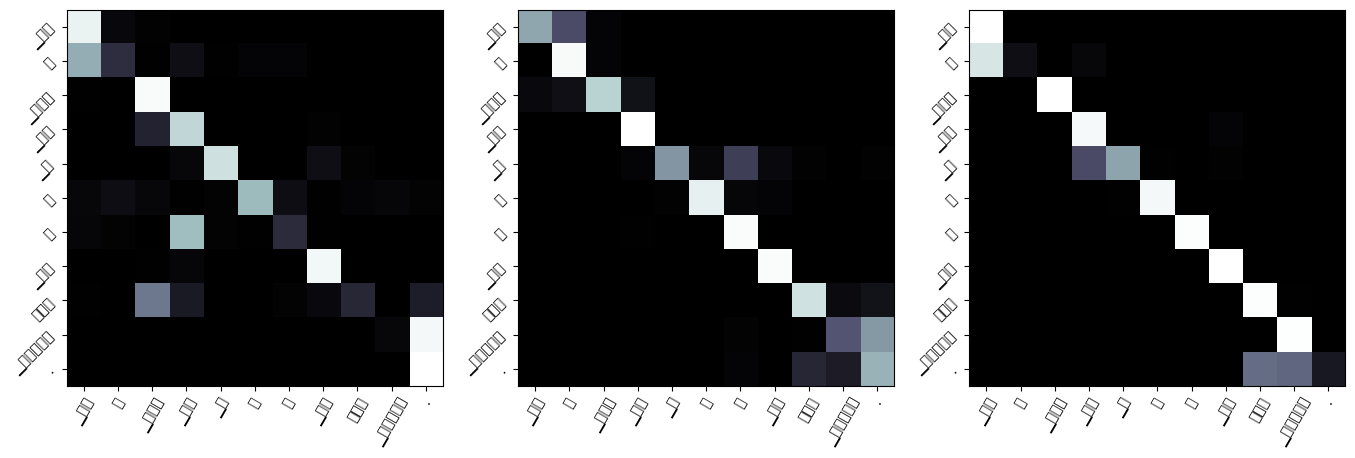

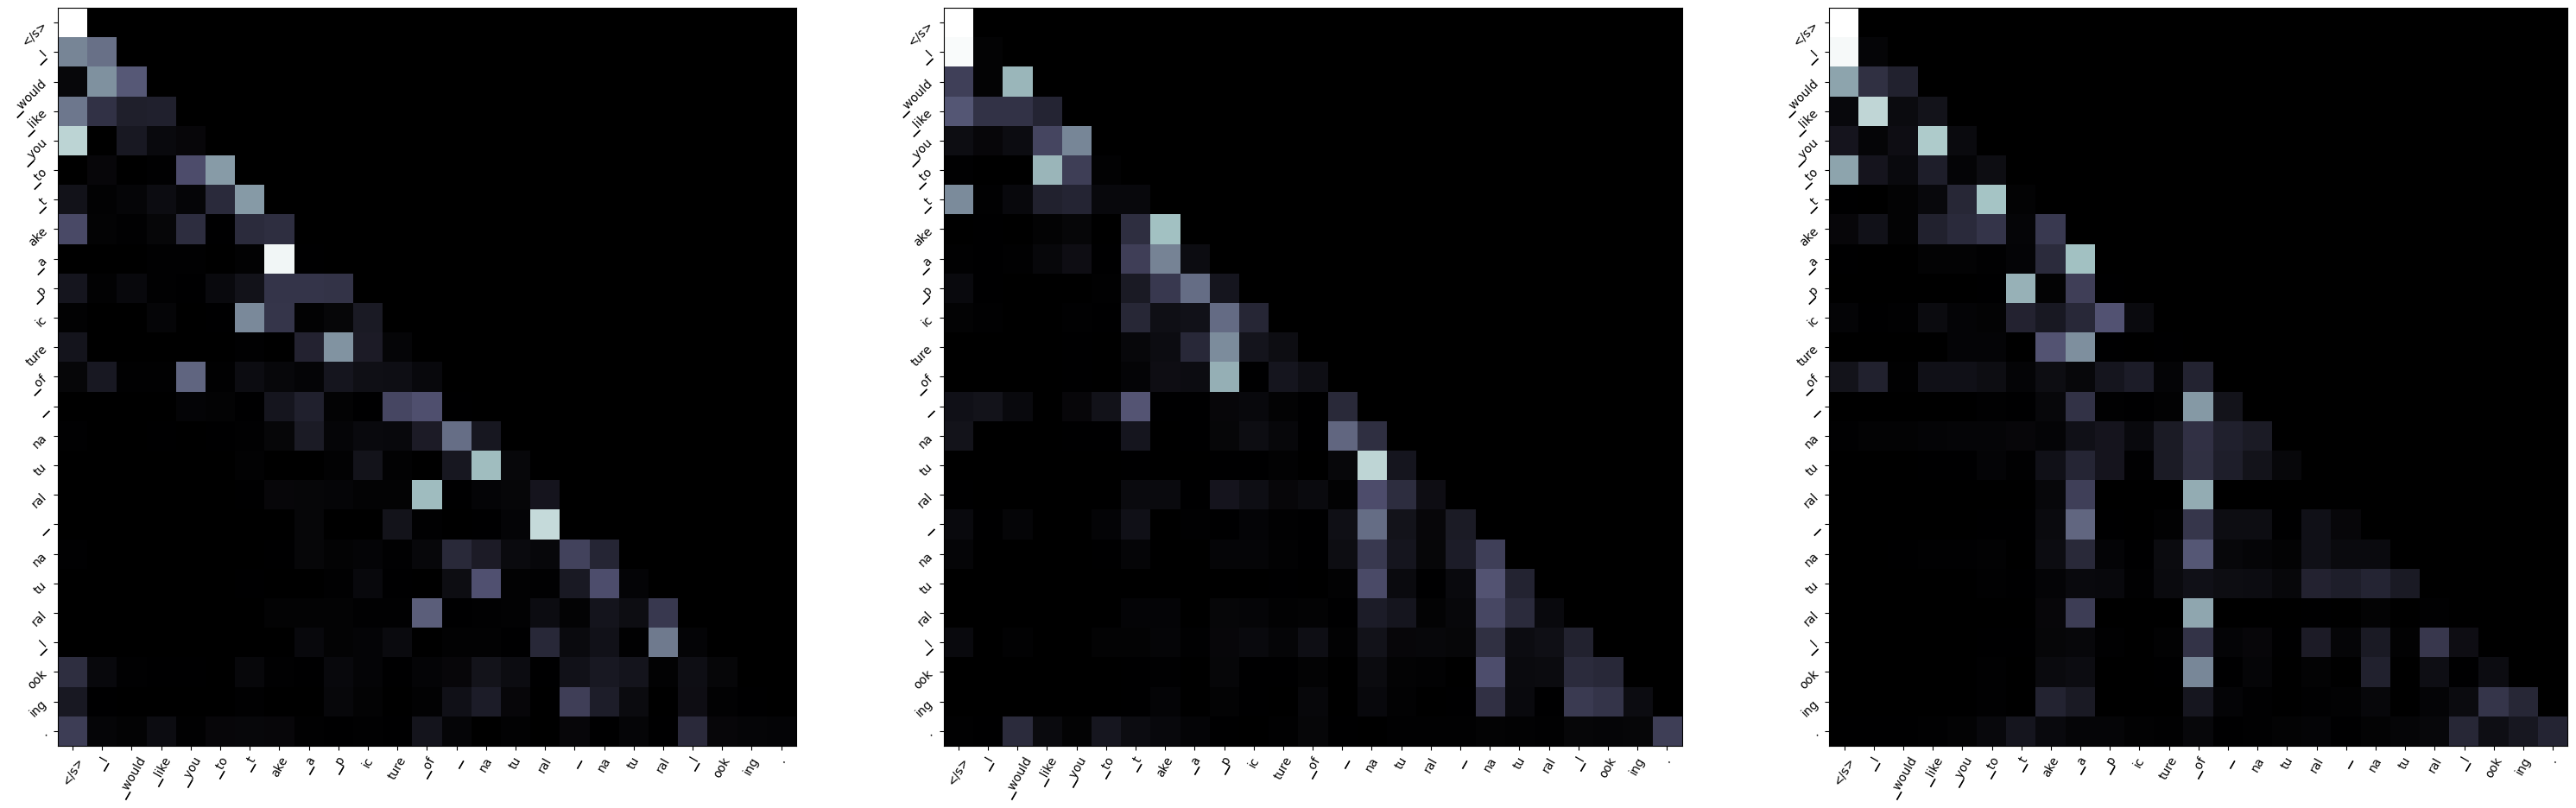

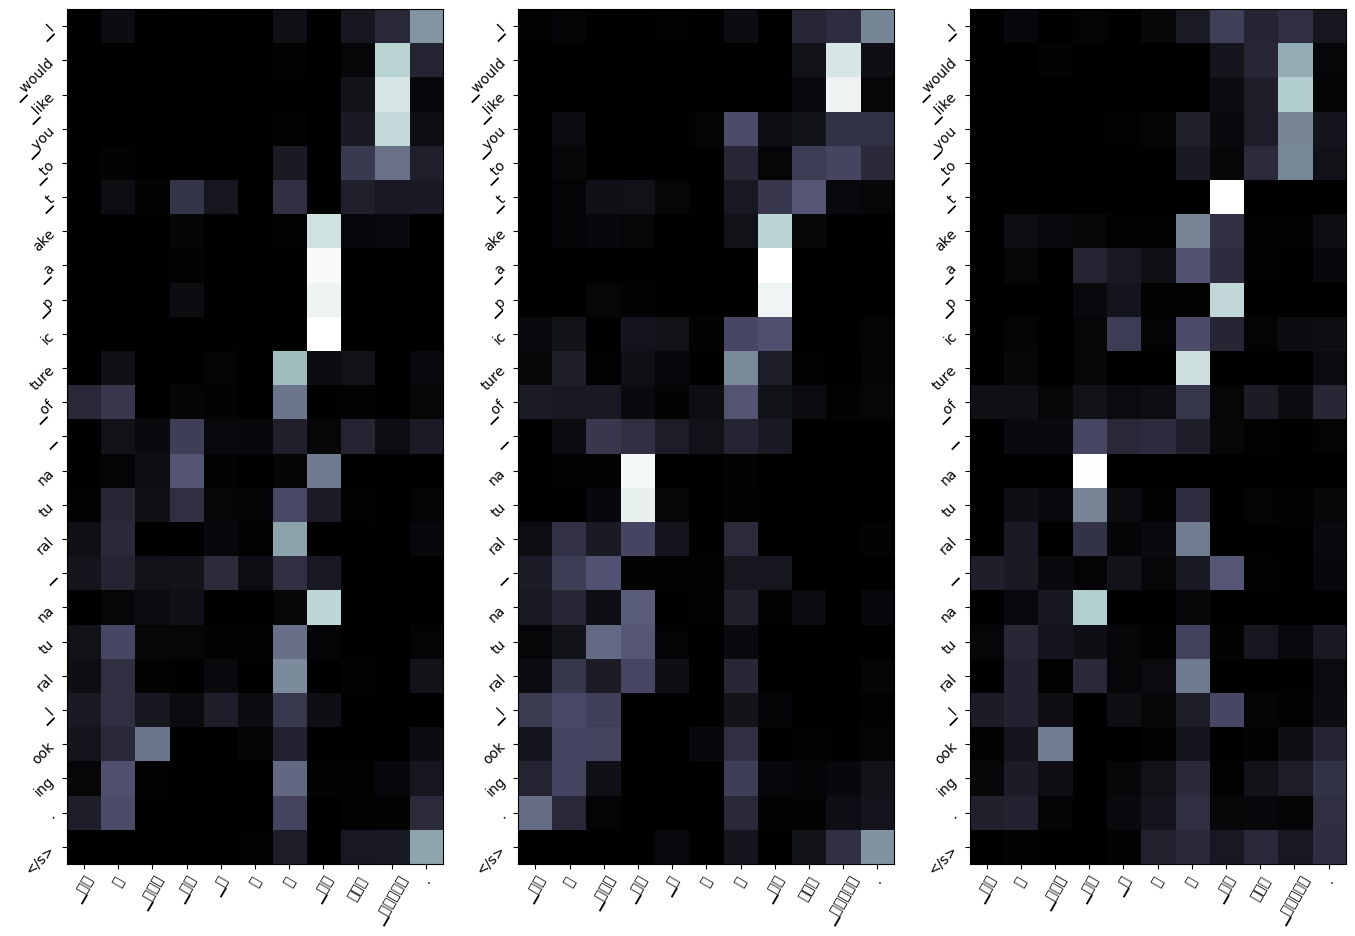

In [40]:
enc_input = tokenizer.tokenize(src_text)
dec_tokens = tokenizer.tokenize(translated_text)
dec_input = dec_tokens[:-1] # 디코더 입력으로 들어가는 문장(sos 는 있고 eos는 없고)
dec_output = dec_tokens[1:] # 디코더 출력으로 나간 문장

# print(dec_input)
# print(atten_enc_dec.shape)
# print(len(dec_input))
# print(len(enc_input))

show_attention(atten_encs, enc_input, enc_input, n = 2)
show_attention(atten_decs, dec_input, dec_input, n = 2)
show_attention(atten_enc_decs, dec_output, enc_input, n = 2)
# "이 단어가 나오게끔 뭘 주목했느냐" 로 해석해줘야 함 (ytick에 들어가는 단어가 아닌 예측한 단어를 썼기 때문)

# 0: 임베딩할 때 어떤 단어를 볼지 나타냄. '찍어' 가 도끼로 찍는다는게 아님 n=0에서 보면 '자연', '에'에 attention함.
#    만약 도끼로 찍는다는 문장이었다면 '도끼'에 attention 할 것!
#    또, n=2에서 보면 '위'는 '위주' 의 '위' 이지 '↑' 이게 아님을 '로', '자연'을 보고 구별한다

# 1: Decoder는 현재까지의 토큰들만 어텐션하는 모습
# 2: 근데 t는 앞엣것들만 보고 임베딩 해야할 텐데.. 'ake', 'each' 이런 단어와 어울리는지 알 수 없지 않을까?
#    땡겨짐! Q만 학습되는거 아니다. K(답변을 잘하자)도 학습된다. 즉, _t는 ake, each 등과 가깝고 zoo 처럼 _t뒤에 안 어울리는 애들과는 멀리 존재하게 됨
#    즉, 꼭 bidirectional 이여야만 뒤의 녀석들에게 영향을 받는 것은 아님 future mask 여도 끌어 땡겨져서 학습되는 것도 있다 (중력처럼!)
# 3: 또, next token prediction의 과정은 't'가 'ake' 또는 'each'으로 변해가는 과정 => 가까울 수밖에 없다
# 4: 근데 'each'이 아닌 'ake'를 선택한 이유는 입력 문장과 't' 앞엣것들 다 보고 선택했기 때문

# 5: 한글 영어 어순이 대체로 반대다보니 '/' 이 모양으로 값이 큰 모습
# 6: 뭘 보고 번역했나: 'take', 'picture', 'like', 'natural' 살펴보기
# 7: 첫 번째 헤드는 natural 출력할 때 왜 자연을 안 봤을까? '찍어'를 봄. ('찍어'에'자연'있다)
# 8: instructor와 강사가 아닌 an과 강사가 가까워진다 (next token prediction) => 여기서는 세 번째 해드에서 't' 가 나오게끔 '찍어'를 봤는데, 이때 Q는 사실 'to' 임! 즉, 'to'와 '찍어'가 가깝다

# 9: layer를 바꿔봄 => 백화점 1층은 사원 헤드 (두루두루) 2층은 부장 헤드 3층은 임원 헤드
# 10: residual block은 보태기 학습하는거니까 레이어마다 많이 달라지는 게 어찌보면 자연스럽고 더 좋은 성능을 기대할 수 있음 (중복되는 정보가 아닌 계속 다양한 각도로 정보를 취합한다)

# 번외: 이어지는 sub-word는 .에 attention 하는 경우

## BLEU score 구하기

In [41]:
!pip install torchtext==0.14.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.1/890.1 MB 837.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.9 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.5.1+cu121
    Uninstalling torch-2.5.1+cu121:
      Successfully uninstalled torch-2.5.1+cu121
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1+cu121 requires torch==2.5.1, but you have torch 1.13.0 which is incompatible.
torchvision 0.20.1+cu121 requires torch==2.5.1, but you have torch 1.13.0 which is in

In [43]:
from torchtext.data.metrics import bleu_score

# trgs = [[['훌륭한', '강사와', '훌륭한', '수강생이','만나면','명강의가', '탄생한다']]]
# preds = [['훌륭한', '강사와', '훌륭한', '수강생이','함께라면','명강의가','만들어진다']]
# preds = [['만들어진다', '강사와', '훌륭한', '명강의가','훌륭한','수강생이','함께라면']]
# preds = [['훌륭한', '강사와', '훌륭한', '수강생이','훌륭한','강사와','훌륭한','강의를', '만든다']]
# preds = [['수강생이', '만나면', '명강의가', '탄생한다']]

trgs = [[['훌륭한', '강사와', '훌륭한', '수강생이','만나면','명강의가', '탄생한다']], [['이것은', '두','번째','문장입니다']]]
preds = [['훌륭한', '강사와', '훌륭한', '수강생이','훌륭한','강의를','만든다'], ['이것은','문장입니다']]

bleu_score(preds, trgs, max_n = 4, weights = [0.25,0.25,0.25,0.25]) # default
# bleu_score(preds, trgs, max_n = 1, weights = [1])

OSError: /usr/local/lib/python3.10/dist-packages/torchtext/lib/libtorchtext.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE

In [44]:
def calc_bleu_score(model, DS):
    trgs = []
    preds = []

    for i, (src_text, trg_text) in enumerate(DS):

        translated_text, _, _, _ = translation(load_model, src_text)

        trg = tokenizer.tokenize(trg_text)
        translated_tok = tokenizer.tokenize(translated_text)[1:-1] # <sos> & <eos> 제외

        trgs += [[trg]]
        preds += [translated_tok]

        if (i + 1) % 100 == 0:
            print(f"[{i + 1}/{len(DS)}]")
            print(f"입력: {src_text}")
            print(f"정답: {trg_text}")
            print(f"AI의 번역: {translated_text[5:-4]}") # 문자열에서 </s> 안보이게 하려고..

    bleu = bleu_score(preds, trgs)
    print()
    print(f'Total BLEU Score = {bleu*100:.2f}')

In [45]:
calc_bleu_score(load_model, test_DS)

[100/1000]
입력: 나는 화장 지울 때만 화장 솜을 쓰는데, 넌 아니야?
정답: I use cotton pad only when I remove my makeup, but what about you?
AI의 번역: I only use my makeup cotton off when I remove it, isn't it?
[200/1000]
입력: 몸살감기인데 아직도 몸이 안 좋아. 그런데 택시비는 회사에 청구하면 되니?
정답: I caught a cold, and I still don’t feel good. By the way, should I charge the taxi fare to the company?
AI의 번역: I'm still not feeling well. Can I charge the taxi fee when I still have a cold?
[300/1000]
입력: 보고서 주신 것을 보니 가셔서 잘 해결하신 것 같습니다.
정답: From what you've reported, I think you've gone and done a good job.
AI의 번역: I think you've been to the report you gave me and solve it well.
[400/1000]
입력: 오일을 원하지 않으시면 사용하지 않고 해드립니다.
정답: I'll do it without using it if you don't want oil.
AI의 번역: If you don't want to don't like oil, we'll use it.
[500/1000]
입력: 그럼 한 시간 동안 이 주변을 빨리 돌아다녀야겠다.
정답: We should go around quickly for an hour.
AI의 번역: Then I'll have to go around while taking this hour.
[600/1000]
입력: 최근에 산 이 가방의 지퍼가 고장 났어요.
정답: The zipper on this bag

NameError: name 'bleu_score' is not defined

In [ ]:
# 내 번역기 써보기!
src_text = "여러분! 제 강의 재밌게 들으셨나요?"
print(f"입력: {src_text}")

translated_text = translation(load_model, src_text)[0]
print(f"AI의 번역: {translated_text}")